In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


URL = (
    "https://www.nodc.noaa.gov/archive/arc0028/0063065/1.1/"
    "data/0-data/ARCSS-PP.csv"
)

path = Path("ARCSS-PP.csv")

if not path.exists():
    df = pd.read_csv(URL, na_values=[-999999, -999999.0])
    df.to_csv(path, index=False)
else:
    df = pd.read_csv(path, na_values=[-999999, -999999.0])

print(df.shape)
print(df.columns.tolist())

(92061, 46)
['IDxyt', 'Year', 'Month', 'Day', 'Time(hrs)', 'Lat', 'Lon', 'OrigStationID', 'IDcruise', 'Source', 'StationDepth(m)', 'IncPAR(uEin/m^2/s)', 'SurfIrr(Einstein/m^2)', 'SampleDepth(m)', 'Pressure(dbar)', 'OpticalDepth', 'SampleInstrument', 'BottleType', 'Chla(mg/m^3)', 'ChlaStdErr(mg/m^3)', 'ChlB(mg/m^3)', 'ChlC(mg/m^3)', 'TotChl(mg/m^3)', 'ChlInstrument', 'ChlMethod', 'ChlFilter', 'Chl_phase', 'Phaeo(mg/m^3)', 'PhaeoStdErr(mg/m^3)', 'PP_phase', 'IncType', 'IncDur(hrs)', 'IncLL(%)', 'IncLL(txt)', 'PP(mg/m^3/hr)', 'PP(mg/m^3/day)', 'PPStdErr(mg/m^3/day)', 'PPInstrument', 'PPFilter', 'PPMethod', 'PPInvestigator', 'Pb(mgC/mgChl/hr)', 'Filename', 'Comments', 'TimeZone', 'Flag']


In [ ]:
%matplotlib widget

In [ ]:
required = [
    "IDxyt",
    "Year",
    "Month",
    "Day",
    "Lat",
    "Lon",
    "StationDepth(m)",
    "SampleDepth(m)",
    "Chla(mg/m^3)",
    "Source",
]

missing = sorted(set(required) - set(df.columns))
if missing:
    raise ValueError(f"Missing columns: {missing}")

chl = df[required].copy()

chl = chl.dropna(
    subset=["IDxyt", "Lat", "Lon", "SampleDepth(m)", "Chla(mg/m^3)"]
)

chl = chl[chl["Chla(mg/m^3)"] >= 0]
chl = chl[chl["SampleDepth(m)"] >= 0]

chl["date"] = pd.to_datetime(
    {
        "year": chl["Year"].astype("Int64"),
        "month": chl["Month"].astype("Int64"),
        "day": chl["Day"].astype("Int64"),
    },
    errors="coerce",
)

print(chl.shape)
print(chl.head())

(80816, 11)
    IDxyt  Year  Month  Day     Lat      Lon  StationDepth(m)  SampleDepth(m)  \
81     99  1993      8   13  70.902 -160.198             53.0             2.0   
82     99  1993      8   13  70.902 -160.198             53.0             7.0   
83     99  1993      8   13  70.902 -160.198             53.0            11.0   
84     99  1993      8   13  70.902 -160.198             53.0            18.0   
85     99  1993      8   13  70.902 -160.198             53.0            50.0   

    Chla(mg/m^3)  Source       date  
81          0.09  ArcNut 1993-08-13  
82          0.09  ArcNut 1993-08-13  
83          0.11  ArcNut 1993-08-13  
84          0.15  ArcNut 1993-08-13  
85          0.23  ArcNut 1993-08-13  


In [ ]:
profile_meta = (
    chl.groupby("IDxyt")
    .agg(
        n_depths=("SampleDepth(m)", "nunique"),
        z_min=("SampleDepth(m)", "min"),
        z_max=("SampleDepth(m)", "max"),
        lat=("Lat", "first"),
        lon=("Lon", "first"),
        station_depth_m=("StationDepth(m)", "first"),
        date=("date", "first"),
        source=("Source", "first"),
    )
)

deep_enough = (
    (
        (profile_meta["station_depth_m"] <= 50)
        & (profile_meta["z_max"] >= (profile_meta["station_depth_m"] - 15))
    )
    |
    (
        (profile_meta["station_depth_m"] > 50)
        & (profile_meta["z_max"] >= 75)
    )
    |
    (
        profile_meta["station_depth_m"].isna()
        & (profile_meta["z_max"] >= 75)
    )
)

valid_profiles = profile_meta[
    (profile_meta["n_depths"] >= 4)
    & (profile_meta["z_min"] <= 10)
    & deep_enough
].copy()

print(valid_profiles.shape)
print(valid_profiles.head())

(5773, 8)
       n_depths  z_min  z_max      lat       lon  station_depth_m       date  \
IDxyt                                                                          
195           6   0.00   40.0  67.6500 -165.7300             42.0 1960-08-21   
197          13   2.08  146.8  79.6464    1.9833           2798.0 1989-04-29   
214           5   0.00   25.0  61.6700 -167.5800             25.0 1959-07-31   
217           4   0.00   16.0  68.0700 -166.3300             26.0 1959-08-05   
227           4   0.00   15.0  66.4500 -166.6300             17.0 1959-08-11   

       source  
IDxyt          
195    ArcNut  
197    ArcNut  
214    ArcNut  
217    ArcNut  
227    ArcNut  


In [ ]:

n_chla_rows = len(chl)

n_raw_profiles = chl["IDxyt"].nunique()

n_valid_profiles = len(valid_profiles)

print(f"Rows with Chl-a: {n_chla_rows}")
print(f"Raw profiles with Chl-a by IDxyt: {n_raw_profiles}")
print(f"Valid vertical profiles after QC: {n_valid_profiles}")
depth_counts = (
    chl.groupby("IDxyt")["SampleDepth(m)"]
    .nunique()
    .sort_values(ascending=False)
)

print(depth_counts.describe())
# print(depth_counts.head(20))

Rows with Chl-a: 80816
Raw profiles with Chl-a by IDxyt: 12389
Valid vertical profiles after QC: 5773
count    12389.000000
mean         6.081685
std          4.244118
min          1.000000
25%          1.000000
50%          6.000000
75%          9.000000
max         61.000000
Name: SampleDepth(m), dtype: float64


In [ ]:

# pip install cartopy

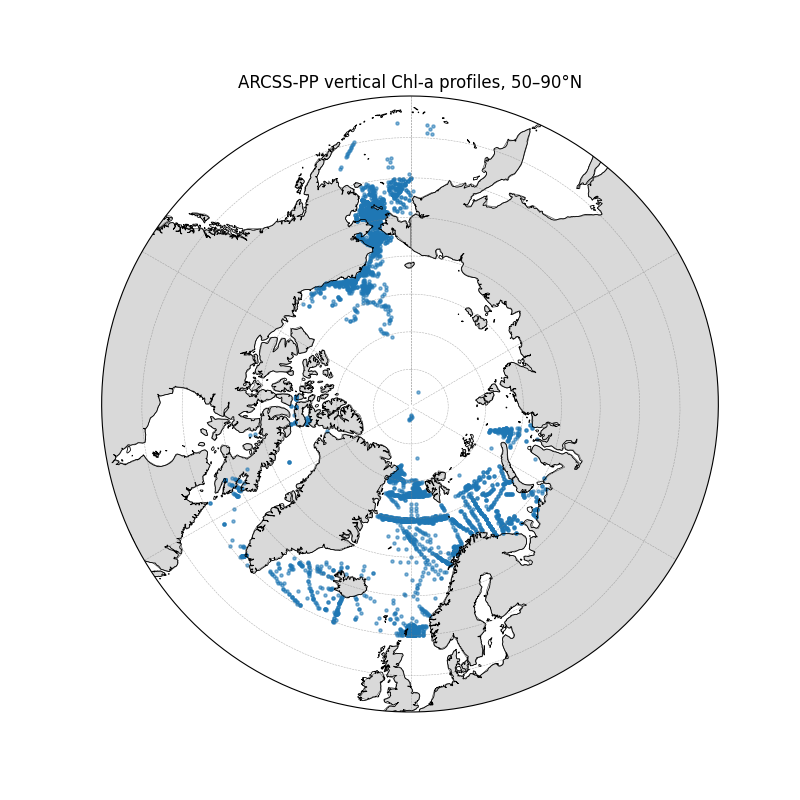

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath

import cartopy.crs as ccrs
import cartopy.feature as cfeature


fig = plt.figure(figsize=(8, 8))

proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)

# Область: вся Арктика от 50 до 90 северной широты
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

# Круглая граница карты
theta = np.linspace(0, 2 * np.pi, 200)
center = np.array([0.5, 0.5])
radius = 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T * radius + center
circle = mpath.Path(verts)
ax.set_boundary(circle, transform=ax.transAxes)

# Материки, береговая линия, океан
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.LAND, facecolor="0.85", edgecolor="0.3", linewidth=0.4)
ax.coastlines(resolution="50m", linewidth=0.6)

# Линии широт/долгот
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.4,
    color="0.5",
    alpha=0.6,
    linestyle="--",
)

# Точки профилей
ax.scatter(
    valid_profiles["lon"],
    valid_profiles["lat"],
    s=5,
    alpha=0.55,
    transform=ccrs.PlateCarree(),
)

ax.set_title("ARCSS-PP vertical Chl-a profiles, 50–90°N")

plt.show()

# for lat in [50, 60, 70, 80]:
#     ax.text(
#         0,
#         lat,
#         f"{lat}°N",
#         transform=ccrs.PlateCarree(),
#         ha="center",
#         va="center",
#         fontsize=9,
#     )

Profiles on map: 126 for years 2000-2005, months=[6, 7]
Using matplotlib backend widget. Click on the polar map to select nearest profiles.


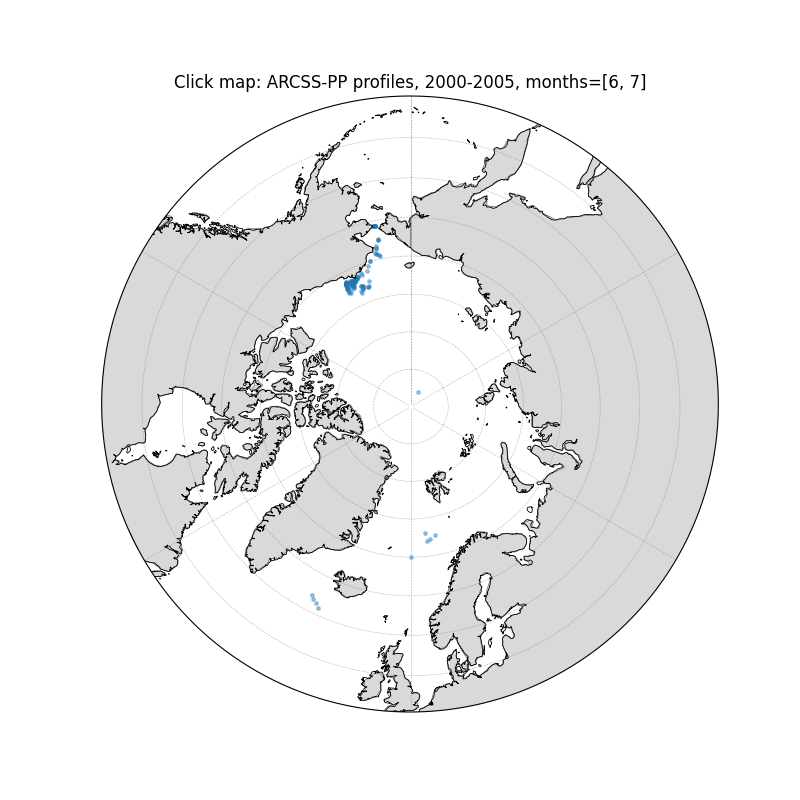

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =========================
# Настройки фильтра
# =========================
year_min = 2000
year_max = 2005
months = [6, 7]       # июнь-июль; можно None, если месяцы не фильтровать

# Сбрасывается при каждом перезапуске ячейки
clicked_profiles = []
clicked_artists = []


# =========================
# Фильтр профилей по датам
# =========================
if "date" not in valid_profiles.columns:
    raise ValueError("Column 'date' is missing in valid_profiles")

profiles_for_map = valid_profiles.copy()
profiles_for_map["date"] = pd.to_datetime(profiles_for_map["date"], errors="coerce")

profiles_for_map = profiles_for_map.dropna(subset=["date"]).copy()
profiles_for_map["year"] = profiles_for_map["date"].dt.year
profiles_for_map["month"] = profiles_for_map["date"].dt.month

mask = profiles_for_map["year"].between(year_min, year_max)

if months is not None:
    mask &= profiles_for_map["month"].isin(months)

profiles_for_map = profiles_for_map[mask].copy()

if profiles_for_map.empty:
    raise ValueError(
        f"No profiles found for years {year_min}-{year_max}, months={months}"
    )

print(
    f"Profiles on map: {len(profiles_for_map)} "
    f"for years {year_min}-{year_max}, months={months}"
)


# =========================
# Проверка backend
# =========================
backend = matplotlib.get_backend().lower().strip()
if "inline" in backend:
    raise RuntimeError(
        "This click selector will not work with the inline matplotlib backend. "
        "Run `%matplotlib widget` (preferred) or `%matplotlib qt`, then rerun the cell."
    )


# =========================
# Карта
# =========================
fig = plt.figure(figsize=(8, 8))

proj = ccrs.NorthPolarStereo()
plate = ccrs.PlateCarree()

ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 50, 90], crs=plate)

# Круглая граница карты
theta = np.linspace(0, 2 * np.pi, 200)
center = np.array([0.5, 0.5])
radius = 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T * radius + center
circle = mpath.Path(verts)
ax.set_boundary(circle, transform=ax.transAxes)

ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.LAND, facecolor="0.85", edgecolor="0.3", linewidth=0.4)
ax.coastlines(resolution="50m", linewidth=0.6)

ax.gridlines(
    crs=plate,
    draw_labels=False,
    linewidth=0.4,
    color="0.5",
    alpha=0.6,
    linestyle="--",
)

# Только профили из выбранного периода
ax.scatter(
    profiles_for_map["lon"],
    profiles_for_map["lat"],
    s=6,
    alpha=0.4,
    transform=plate,
)

ax.set_title(
    f"Click map: ARCSS-PP profiles, {year_min}-{year_max}, months={months}"
)


# =========================
# Координаты только отфильтрованных профилей
# =========================
lons = profiles_for_map["lon"].to_numpy(float)
lats = profiles_for_map["lat"].to_numpy(float)
profile_ids = profiles_for_map.index.to_numpy()

xy = proj.transform_points(plate, lons, lats)
xs = xy[:, 0]
ys = xy[:, 1]

finite = np.isfinite(xs) & np.isfinite(ys)
if not np.any(finite):
    raise ValueError("No valid projected profile coordinates were found.")

xs = xs[finite]
ys = ys[finite]
lons = lons[finite]
lats = lats[finite]
profile_ids = profile_ids[finite]


def on_click_nearest_profile(event):
    if event.inaxes is not ax:
        return

    if event.xdata is None or event.ydata is None:
        try:
            x_proj, y_proj = ax.transData.inverted().transform((event.x, event.y))
        except Exception:
            return
    else:
        x_proj, y_proj = event.xdata, event.ydata

    dist2 = (xs - x_proj) ** 2 + (ys - y_proj) ** 2
    i = int(np.nanargmin(dist2))

    pid = profile_ids[i]
    lon = lons[i]
    lat = lats[i]

    meta = profiles_for_map.loc[pid]

    order = len(clicked_profiles) + 1

    # В массив сохраняем только IDxyt
    pid_value = pid.item() if hasattr(pid, "item") else pid
    clicked_profiles.append(pid_value)

    date_str = pd.to_datetime(meta["date"]).strftime("%Y-%m-%d")

    print(
        f"[{order}] IDxyt={pid}, "
        f"date={date_str}, "
        f"lon={lon:.3f}, lat={lat:.3f}, "
        f"n_depths={meta['n_depths']}, "
        f"z_max={meta['z_max']:.1f} m"
    )

    # На карте показываем порядковый номер клика
    marker = ax.scatter(
        [lon],
        [lat],
        s=120,
        marker="o",
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        transform=plate,
        zorder=10,
    )

    text = ax.text(
        lon,
        lat,
        str(order),
        transform=plate,
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        zorder=11,
    )

    clicked_artists.extend([marker, text])
    fig.canvas.draw_idle()


cid_click = fig.canvas.mpl_connect("button_press_event", on_click_nearest_profile)

print(
    f"Using matplotlib backend {matplotlib.get_backend()}. "
    "Click on the polar map to select nearest profiles."
)

plt.show()

In [ ]:
clicked_profiles

[13834, 13782, 14027, 17182, 19402]

In [ ]:
profiles = valid_profiles.copy()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# --- Настройки ---
z_plot_max = 150

# clicked_profiles должен быть списком IDxyt, например:
# clicked_profiles = [12345, 12346, 12347]

if not clicked_profiles:
    raise ValueError("clicked_profiles is empty. Сначала выбери профили кликами на карте.")

# Убираем дубли, сохраняем порядок выбора
profile_ids = list(dict.fromkeys(clicked_profiles))

# Fail-fast: проверяем, что все выбранные IDxyt есть в valid_profiles
missing_ids = [pid for pid in profile_ids if pid not in valid_profiles.index]
if missing_ids:
    raise ValueError(f"These IDxyt are missing in valid_profiles: {missing_ids}")

profiles_to_plot = valid_profiles.loc[profile_ids].copy()

if "date" not in profiles_to_plot.columns:
    raise ValueError("Column 'date' is missing in valid_profiles")

# Цвета Plotly
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#393b79", "#637939",
]


fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "geo"}, {"type": "xy"}]],
    column_widths=[0.55, 0.45],
    subplot_titles=[
        "Locations of clicked profiles",
        f"Vertical Chl-a profiles, 0–{z_plot_max} m",
    ],
)


# --- Фон: все валидные профили, очень бледно ---
fig.add_trace(
    go.Scattergeo(
        lon=valid_profiles["lon"],
        lat=valid_profiles["lat"],
        mode="markers",
        marker=dict(
            size=3,
            color="rgba(80,80,80,0.12)",
        ),
        name="All valid profiles",
        showlegend=False,
        hoverinfo="skip",
    ),
    row=1,
    col=1,
)


# --- Только выбранные clicked_profiles ---
for k, pid in enumerate(profile_ids):
    meta = valid_profiles.loc[pid]
    color = colors[k % len(colors)]

    date = pd.to_datetime(meta["date"], errors="coerce")
    date_label = "unknown date" if pd.isna(date) else date.strftime("%Y-%m")

    label = f"IDxyt={pid} | {date_label} | {meta['lat']:.1f}°N, {meta['lon']:.1f}°E"
    group = f"profile_{pid}"

    p = (
        chl[chl["IDxyt"] == pid]
        .groupby("SampleDepth(m)", as_index=False)["Chla(mg/m^3)"]
        .mean()
        .sort_values("SampleDepth(m)")
    )

    p = p[p["SampleDepth(m)"] <= z_plot_max]

    if p.empty:
        raise ValueError(f"No Chl-a points for IDxyt={pid} within 0–{z_plot_max} m")

    # Точка на карте
    fig.add_trace(
        go.Scattergeo(
            lon=[meta["lon"]],
            lat=[meta["lat"]],
            mode="markers+text",
            marker=dict(
                size=9,
                color=color,
                line=dict(width=0.7, color="black"),
            ),
            text=[str(pid)],
            textposition="top center",
            textfont=dict(size=9),
            name=label,
            legendgroup=group,
            showlegend=False,
            hovertemplate=(
                f"IDxyt={pid}<br>"
                f"date={date_label}<br>"
                "lat=%{lat:.2f}<br>"
                "lon=%{lon:.2f}<br>"
                f"n_depths={meta['n_depths']}<br>"
                f"z_max={meta['z_max']:.1f} m"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=1,
    )

    # Вертикальный профиль
    fig.add_trace(
        go.Scatter(
            x=p["Chla(mg/m^3)"],
            y=p["SampleDepth(m)"],
            mode="lines+markers",
            marker=dict(size=5, color=color),
            line=dict(width=1.5, color=color),
            name=label,
            legendgroup=group,
            showlegend=True,
            hovertemplate=(
                f"IDxyt={pid}<br>"
                f"date={date_label}<br>"
                "Chl-a=%{x:.3f} mg m⁻³<br>"
                "Depth=%{y:.1f} m"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=2,
    )


fig.update_geos(
    projection_type="stereographic",
    projection_rotation=dict(lat=90),
    lataxis=dict(range=[50, 90]),
    lonaxis=dict(range=[-180, 180]),
    showland=True,
    landcolor="rgb(220,220,220)",
    showocean=True,
    oceancolor="white",
    showcountries=False,
    coastlinecolor="rgb(80,80,80)",
    coastlinewidth=0.6,
    showlakes=False,
    showrivers=False,
    bgcolor="white",
)


fig.update_xaxes(
    title_text="Chl-a, mg m⁻³",
    row=1,
    col=2,
)

fig.update_yaxes(
    title_text="Depth, m",
    autorange="reversed",
    range=[z_plot_max, 0],
    row=1,
    col=2,
)

fig.update_layout(
    width=1250,
    height=700,
    title="ARCSS-PP clicked vertical Chl-a profiles",
    template="plotly_white",
    legend=dict(
        title="Click to hide/show profile",
        groupclick="togglegroup",
        itemsizing="constant",
    ),
    margin=dict(l=20, r=20, t=70, b=20),
)

fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# =========================
# Настройки
# =========================
z_plot_max = 150

lat_min_data = 50   # какие точки показываем
lat_min_map = 40    # граница карты ниже, чтобы был воздух
lat_max = 90
projection_scale = 0.90


# Если есть profiles_for_map после фильтра по годам/месяцам — используем его для фона.
# Если нет — берём valid_profiles.
try:
    profiles_bg = profiles_for_map.copy()
except NameError:
    profiles_bg = valid_profiles.copy()

profiles_bg = profiles_bg[
    profiles_bg["lat"].between(lat_min, lat_max)
].copy()


if not clicked_profiles:
    raise ValueError("clicked_profiles is empty. Сначала выбери профили кликами на карте.")

# Убираем дубли, сохраняем порядок выбора
profile_ids = list(dict.fromkeys(clicked_profiles))

missing_ids = [pid for pid in profile_ids if pid not in valid_profiles.index]
if missing_ids:
    raise ValueError(f"These IDxyt are missing in valid_profiles: {missing_ids}")

profiles_to_plot = valid_profiles.loc[profile_ids].copy()

if "date" not in profiles_to_plot.columns:
    raise ValueError("Column 'date' is missing in valid_profiles")


colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#393b79", "#637939",
]


fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "geo"}, {"type": "xy"}]],
    column_widths=[0.52, 0.48],
    horizontal_spacing=0.06,
    subplot_titles=[
        "Locations of clicked profiles",
        f"Vertical Chl-a profiles, 0–{z_plot_max} m",
    ],
)


# =========================
# Карта: фоновые профили
# =========================
profiles_bg = valid_profiles[
    valid_profiles["lat"].between(lat_min_data, lat_max)
].copy()

fig.add_trace(
    go.Scattergeo(
        lon=profiles_bg["lon"],
        lat=profiles_bg["lat"],
        mode="markers",
        marker=dict(
            size=3,
            color="rgba(70,70,70,0.18)",
        ),
        name="Background profiles",
        showlegend=False,
        hoverinfo="skip",
    ),
    row=1,
    col=1,
)


# =========================
# Выбранные профили
# =========================
for k, pid in enumerate(profile_ids):
    meta = valid_profiles.loc[pid]
    color = colors[k % len(colors)]

    date = pd.to_datetime(meta["date"], errors="coerce")
    date_label = "unknown date" if pd.isna(date) else date.strftime("%Y-%m")

    label = f"IDxyt={pid} | {date_label} | {meta['lat']:.1f}°N, {meta['lon']:.1f}°E"
    group = f"profile_{pid}"

    p = (
        chl[chl["IDxyt"] == pid]
        .groupby("SampleDepth(m)", as_index=False)["Chla(mg/m^3)"]
        .mean()
        .sort_values("SampleDepth(m)")
    )

    p = p[p["SampleDepth(m)"] <= z_plot_max]

    if p.empty:
        raise ValueError(f"No Chl-a points for IDxyt={pid} within 0–{z_plot_max} m")

    # Точка на карте
    fig.add_trace(
        go.Scattergeo(
            lon=[meta["lon"]],
            lat=[meta["lat"]],
            mode="markers+text",
            marker=dict(
                size=10,
                color=color,
                line=dict(width=1.0, color="black"),
            ),
            text=[str(pid)],
            textposition="top center",
            textfont=dict(size=9, color="black"),
            name=label,
            legendgroup=group,
            showlegend=False,
            hovertemplate=(
                f"IDxyt={pid}<br>"
                f"date={date_label}<br>"
                "lat=%{lat:.2f}<br>"
                "lon=%{lon:.2f}<br>"
                f"n_depths={meta['n_depths']}<br>"
                f"z_max={meta['z_max']:.1f} m"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=1,
    )

    # Вертикальный профиль
    fig.add_trace(
        go.Scatter(
            x=p["Chla(mg/m^3)"],
            y=p["SampleDepth(m)"],
            mode="lines+markers",
            marker=dict(size=5, color=color),
            line=dict(width=1.6, color=color),
            name=label,
            legendgroup=group,
            showlegend=True,
            hovertemplate=(
                f"IDxyt={pid}<br>"
                f"date={date_label}<br>"
                "Chl-a=%{x:.3f} mg m⁻³<br>"
                "Depth=%{y:.1f} m"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=2,
    )


# =========================
# Оформление круглой карты
# =========================
fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=90, lon=0),
    projection_scale=projection_scale,

    lataxis=dict(
        range=[lat_min_map, lat_max],
        showgrid=True,
        gridcolor="rgba(120,120,120,0.35)",
        gridwidth=0.6,
    ),
    lonaxis=dict(
        range=[-180, 180],
        showgrid=True,
        gridcolor="rgba(120,120,120,0.35)",
        gridwidth=0.6,
    ),

    showland=True,
    landcolor="rgb(225,225,225)",
    showocean=True,
    oceancolor="rgb(248,248,248)",
    showcountries=False,
    showcoastlines=True,
    coastlinecolor="rgb(70,70,70)",
    coastlinewidth=0.7,
    showlakes=False,
    showrivers=False,
    showframe=True,
    framecolor="rgb(80,80,80)",
    framewidth=1.0,
    bgcolor="white",
    resolution=50,
)


# =========================
# Оформление профилей
# =========================
fig.update_xaxes(
    title_text="Chl-a, mg m⁻³",
    row=1,
    col=2,
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    gridcolor="rgba(150,150,150,0.25)",
)

fig.update_yaxes(
    title_text="Depth, m",
    autorange="reversed",
    range=[z_plot_max, 0],
    row=1,
    col=2,
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    gridcolor="rgba(150,150,150,0.25)",
)


fig.update_layout(
    width=1250,
    height=720,
    title="ARCSS-PP clicked vertical Chl-a profiles",
    template="plotly_white",
    legend=dict(
        title="Click to hide/show profile",
        groupclick="togglegroup",
        itemsizing="constant",
        x=1.02,
        y=0.5,
        xanchor="left",
        yanchor="middle",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(180,180,180,0.7)",
        borderwidth=1,
        font=dict(size=10),
    ),
    margin=dict(l=20, r=20, t=75, b=25),
)

fig.show()

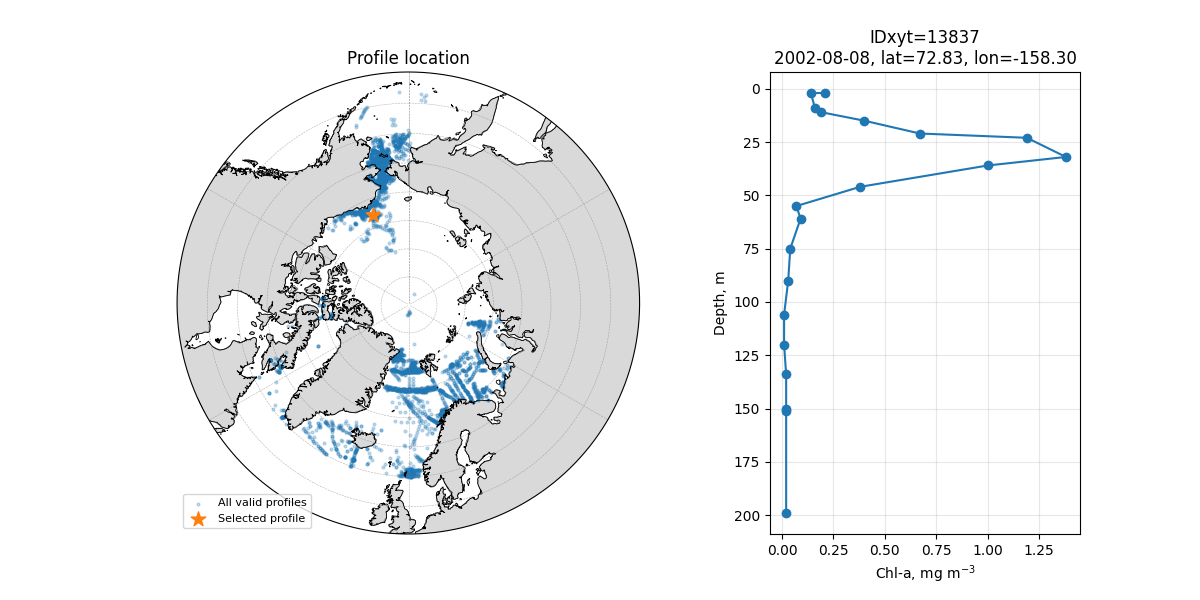

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mpath

import cartopy.crs as ccrs
import cartopy.feature as cfeature

subset = valid_profiles[
    (valid_profiles["lat"].between(68, 78))
    & (valid_profiles["lon"].between(-160, -120))
]

profile_id = subset.sort_values("n_depths", ascending=False).index[0]

# # Берём профиль с максимальным числом глубин
# profile_id = valid_profiles.sort_values("n_depths", ascending=False).index[0]

meta = valid_profiles.loc[profile_id]

p = (
    chl[chl["IDxyt"] == profile_id]
    .groupby("SampleDepth(m)", as_index=False)["Chla(mg/m^3)"]
    .mean()
    .sort_values("SampleDepth(m)")
)

date_str = (
    pd.to_datetime(meta["date"]).strftime("%Y-%m-%d")
    if pd.notna(meta["date"])
    else "date unknown"
)

title = (
    f"IDxyt={profile_id}\n"
    f"{date_str}, lat={meta['lat']:.2f}, lon={meta['lon']:.2f}"
)

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 0.75], wspace=0.25)

# --- Левая панель: карта ---
proj = ccrs.NorthPolarStereo()
ax_map = fig.add_subplot(gs[0, 0], projection=proj)

ax_map.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

# Круглая рамка карты
theta = np.linspace(0, 2 * np.pi, 200)
center = np.array([0.5, 0.5])
radius = 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T * radius + center
circle = mpath.Path(verts)
ax_map.set_boundary(circle, transform=ax_map.transAxes)

ax_map.add_feature(cfeature.OCEAN, facecolor="white")
ax_map.add_feature(cfeature.LAND, facecolor="0.85", edgecolor="0.3", linewidth=0.4)
ax_map.coastlines(resolution="50m", linewidth=0.6)

ax_map.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.4,
    color="0.5",
    alpha=0.6,
    linestyle="--",
)

# Все валидные профили
ax_map.scatter(
    valid_profiles["lon"],
    valid_profiles["lat"],
    s=4,
    alpha=0.25,
    transform=ccrs.PlateCarree(),
    label="All valid profiles",
)

# Выбранный профиль
ax_map.scatter(
    [meta["lon"]],
    [meta["lat"]],
    s=120,
    marker="*",
    transform=ccrs.PlateCarree(),
    label="Selected profile",
)

ax_map.set_title("Profile location")
ax_map.legend(loc="lower left", fontsize=8, frameon=True)

# --- Правая панель: вертикальный профиль ---
ax_prof = fig.add_subplot(gs[0, 1])

ax_prof.plot(
    p["Chla(mg/m^3)"],
    p["SampleDepth(m)"],
    marker="o",
    linewidth=1.5,
)

ax_prof.invert_yaxis()
ax_prof.set_xlabel("Chl-a, mg m$^{-3}$")
ax_prof.set_ylabel("Depth, m")
ax_prof.set_title(title)
ax_prof.grid(True, alpha=0.3)

plt.show()

In [ ]:
profiles = valid_profiles.copy()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# --- Настройка ---
profiles = valid_profiles.copy()   # или profile_meta.copy()

if "date" not in profiles.columns:
    raise ValueError("Column 'date' is missing. Нужно сначала собрать profile_meta / valid_profiles с колонкой date.")

profiles["date"] = pd.to_datetime(profiles["date"], errors="coerce")
profiles = profiles.dropna(subset=["date"]).copy()

profiles["year"] = profiles["date"].dt.year
profiles["month"] = profiles["date"].dt.month

print(f"Number of profiles: {len(profiles)}")
print(f"Years: {profiles['year'].min()}–{profiles['year'].max()}")
print("Months:", sorted(profiles["month"].unique()))

year_counts = profiles.groupby("year").size()
month_counts = profiles.groupby("month").size()
year_month_counts = (
    profiles
    .groupby(["year", "month"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)

Number of profiles: 5773
Years: 1954–2004
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


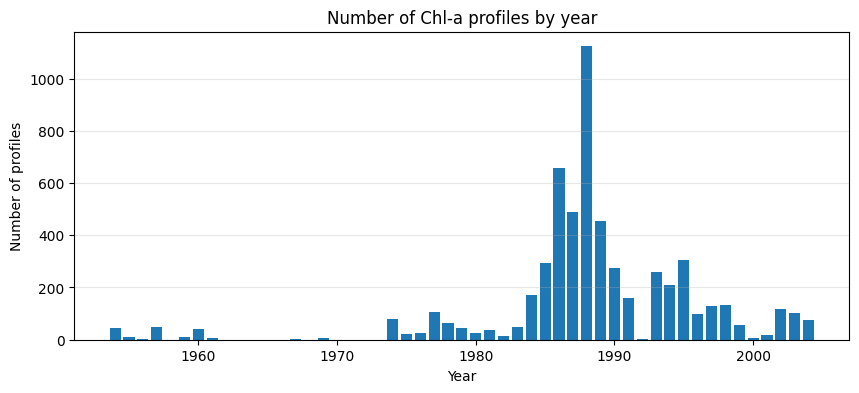

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of profiles")
plt.title("Number of Chl-a profiles by year")
plt.grid(axis="y", alpha=0.3)
plt.show()

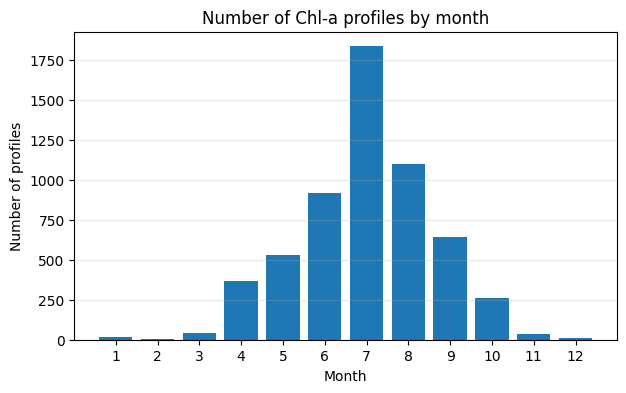

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(month_counts.index, month_counts.values)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Number of profiles")
plt.title("Number of Chl-a profiles by month")
plt.grid(axis="y", alpha=0.3)
plt.show()

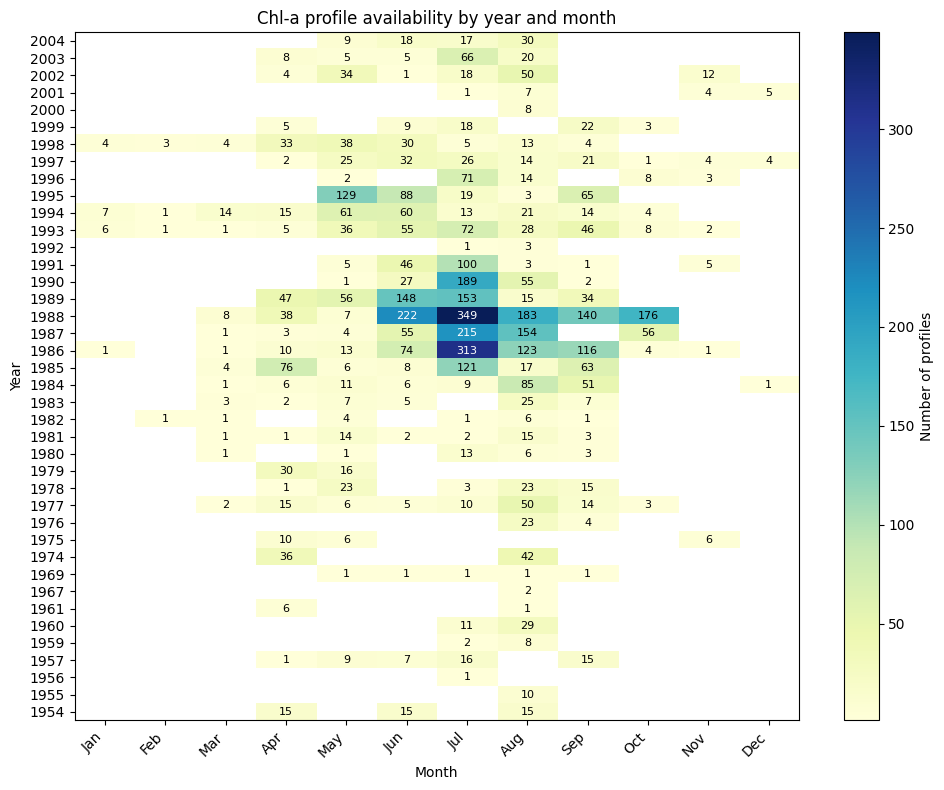

year
1954                              [4, 6, 8]
1955                                    [8]
1956                                    [7]
1957                        [4, 5, 6, 7, 9]
1959                                 [7, 8]
1960                                 [7, 8]
1961                                 [4, 8]
1967                                    [8]
1969                        [5, 6, 7, 8, 9]
1974                                 [4, 8]
1975                             [4, 5, 11]
1976                                 [8, 9]
1977              [3, 4, 5, 6, 7, 8, 9, 10]
1978                        [4, 5, 7, 8, 9]
1979                                 [4, 5]
1980                        [3, 5, 7, 8, 9]
1981                  [3, 4, 5, 6, 7, 8, 9]
1982                     [2, 3, 5, 7, 8, 9]
1983                     [3, 4, 5, 6, 8, 9]
1984              [3, 4, 5, 6, 7, 8, 9, 12]
1985                  [3, 4, 5, 6, 7, 8, 9]
1986       [1, 3, 4, 5, 6, 7, 8, 9, 10, 11]
1987                 [3, 4,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data = year_month_counts.values

# Нули маскируем, чтобы они были белыми
masked_data = np.ma.masked_where(data == 0, data)

cmap = plt.colormaps["YlGnBu"].copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    masked_data,
    aspect="auto",
    origin="lower",
    cmap=cmap,
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of profiles")

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, rotation=45, ha="right")

ax.set_yticks(range(len(year_month_counts.index)))
ax.set_yticklabels(year_month_counts.index)

ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_title("Chl-a profile availability by year and month")

# Подписи чисел
vmax = data.max()

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]

        if value == 0:
            continue

        text_color = "white" if value > 0.6 * vmax else "black"

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=8,
            color=text_color,
        )

plt.tight_layout()
plt.show()
months_by_year = (
    profiles
    .groupby("year")["month"]
    .apply(lambda x: sorted(x.unique()))
)

months_by_year